In [1]:
# load data
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("ForeignGifts_edu.csv")
# avoiding scientific notation  
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df['Foreign Gift Received Date'] = pd.to_datetime(
    df['Foreign Gift Received Date'],
    unit = 'D',
    origin = '1899-12-30'
)
# was baffled by why the dates were just random integers - they're serial dates representing days since 1899-12-30

In [3]:
oldest = df["Foreign Gift Received Date"].min()
newest = df["Foreign Gift Received Date"].max()

print(f"Oldest gift date: {oldest}")
print(f"Most recent gift date: {newest}")

Oldest gift date: 2014-01-01 00:00:00
Most recent gift date: 2020-06-30 00:00:00


In [4]:
# isolating uva data
uva = df[df["Institution Name"] == "University of Virginia"]
# checking that i captured it
uva["Institution Name"].unique()

<StringArray>
['University of Virginia']
Length: 1, dtype: str

Describing UVA's foreign giving on its own.

In [5]:
print(f"Number of UVA gift records: {len(uva)}")
uva.head()

Number of UVA gift records: 98


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,2014-07-02,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,2014-08-19,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,2014-08-22,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,2014-09-05,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,2014-09-22,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [6]:
# total money received
total_received = uva["Foreign Gift Amount"].sum()
print(f"Total money received by UVA: ${total_received:,.2f}")

Total money received by UVA: $22,189,238.00


In [7]:
# gift count
gift_count = len(uva)
print(f"Number of UVA gifts: {gift_count}")

Number of UVA gifts: 98


In [8]:
# mean v median gift size
mean_gift_size = uva["Foreign Gift Amount"].mean()
median_gift_size = uva["Foreign Gift Amount"].median()
print(f"Mean gift size: ${mean_gift_size:,.2f}")
print(f"Median gift size: ${median_gift_size:,.2f}")
print(f"Difference between mean and median: ${mean_gift_size - median_gift_size:,.2f}")

Mean gift size: $226,420.80
Median gift size: $80,535.50
Difference between mean and median: $145,885.30


In [9]:
# full descriptive statistics
uva["Foreign Gift Amount"].describe()

count        98.0000
mean     226420.7959
std      343305.1476
min          31.0000
25%        9450.0000
50%       80535.5000
75%      276888.2500
max     1708021.0000
Name: Foreign Gift Amount, dtype: float64

In [10]:
# top countries giving to UVA
top_countries = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .agg(total="sum", count="count", mean="mean")
    .sort_values("total", ascending=False)
)
print(top_countries.head(10))


                     total  count         mean
Country of Giftor                             
BANGLADESH         4228589     10  422858.9000
SWEDEN             4007552     10  400755.2000
TANZANIA           2776447      3  925482.3333
SWITZERLAND        2000000      2 1000000.0000
ENGLAND            1950666     31   62924.7097
GUERNSEY           1500000      3  500000.0000
FINLAND            1008384      7  144054.8571
BERMUDA             900000      1  900000.0000
KOREA               862787      6  143797.8333
SINGAPORE           805000      2  402500.0000


UVA's largest total contributions by country are one-off large gifts rather than sustained relationships: Bangladesh ($4.2M across 10 gifts), Sweden ($4.0M across 10 gifts), and Tanzania ($2.8M across just 3 gifts, averaging over $925K per gift) top the list. England is the one country with a genuinely broad relationship — 31 separate gifts totaling $1.95M, more gift *records* than any other country, but at a modest average size (~$63K each). That split matters for strategy: Bangladesh/Tanzania-style windfalls are hard to plan around or replicate, while England-style relationships (many smaller, recurring gifts) are the kind that can realistically be grown through deliberate outreach.

                              total  count
Foreign Gift Received Date                
2014                        1050235     15
2015                        3349261     10
2016                        6780205     31
2017                        4422550     25
2018                        2607739      9
2019                        3979248      8


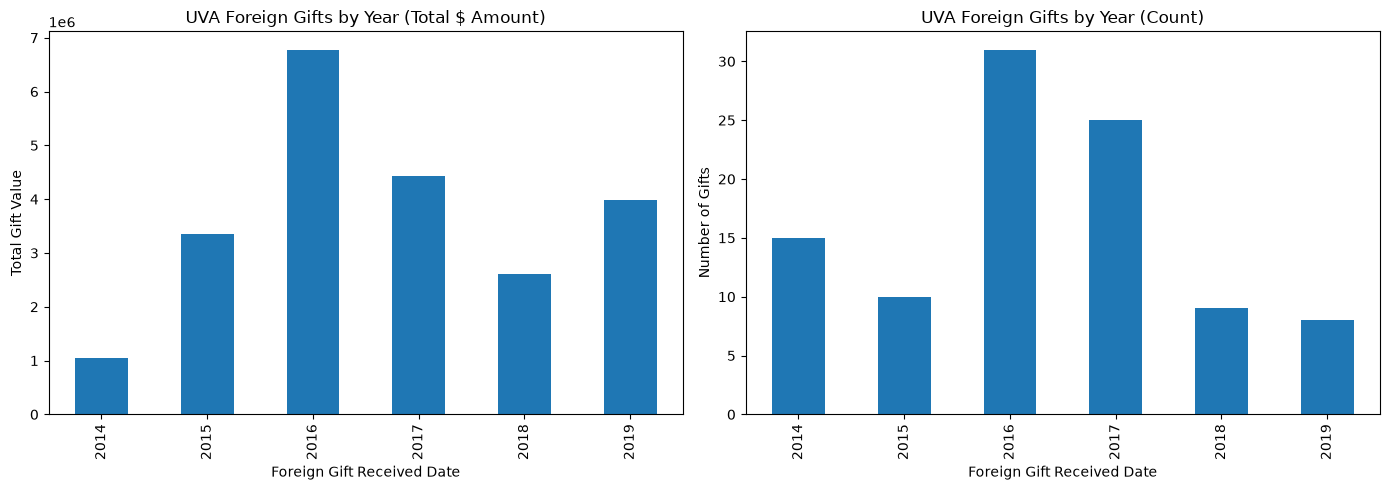

In [11]:
uva_by_year = uva.groupby(uva["Foreign Gift Received Date"].dt.year)["Foreign Gift Amount"].agg(total="sum", count="count")
print(uva_by_year)

# visualizing trend over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
uva_by_year["total"].plot(kind="bar", ax=axes[0], title="UVA Foreign Gifts by Year (Total $ Amount)")
axes[0].set_ylabel("Total Gift Value")
uva_by_year["count"].plot(kind="bar", ax=axes[1], title="UVA Foreign Gifts by Year (Count)")
axes[1].set_ylabel("Number of Gifts")
plt.tight_layout()
plt.show()


UVA's foreign giving peaked in 2016 ($6.78M across 31 gifts), then declined and stayed choppier through 2019 ($1.05M-$4.4M/year). There's no 2019→2020 bar because UVA has zero recorded gifts in 2020 — but that's not necessarily a real drop-off: the whole dataset only covers gifts through June 30, 2020, so 2020 is a half-year at best and shouldn't be read as a trend.

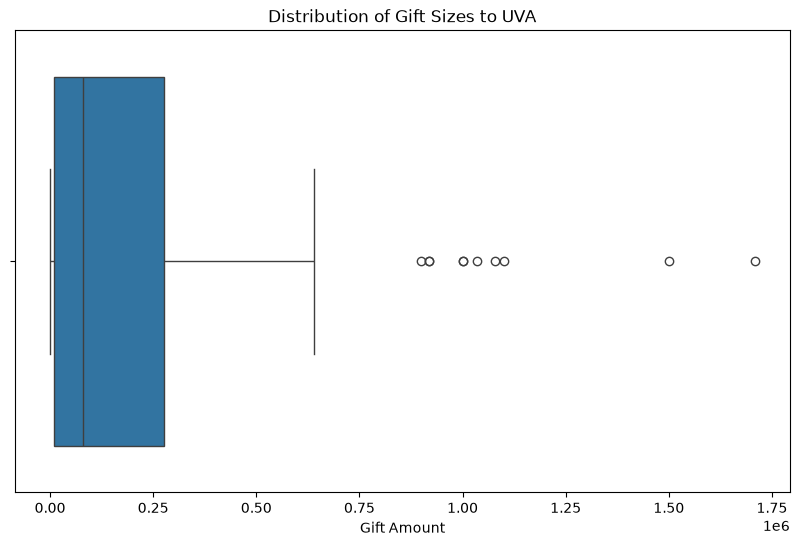

In [12]:
# showing distribution shape
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=uva["Foreign Gift Amount"])
plt.title("Distribution of Gift Sizes to UVA")
plt.xlabel("Gift Amount")
plt.show()

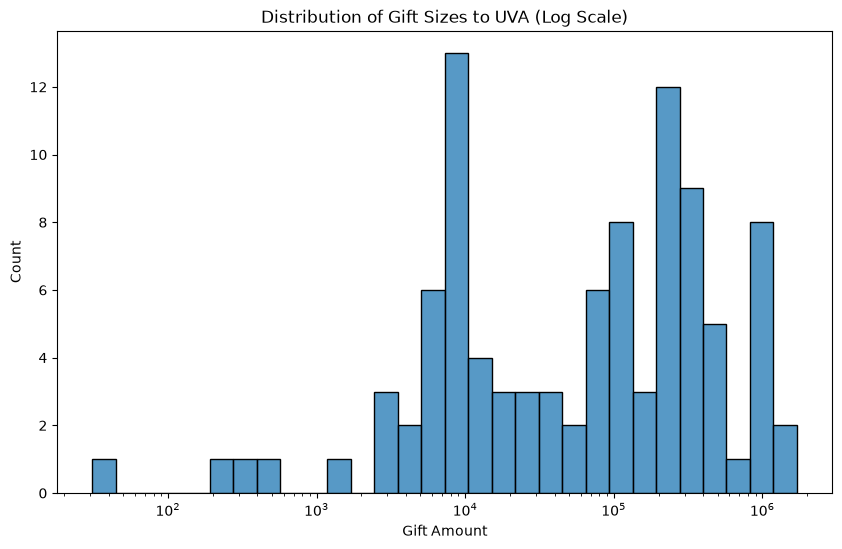

In [13]:
# distribution on log scale because of the severe skew 
plt.figure(figsize=(10, 6))
sns.histplot(uva["Foreign Gift Amount"], bins=30, log_scale=True)
plt.title("Distribution of Gift Sizes to UVA (Log Scale)")
plt.xlabel("Gift Amount")
plt.show()

The log-scale histogram confirms the shape suggested by the mean/median gap: most of UVA's 98 gifts cluster in the tens-of-thousands-to-low-hundred-thousands range, with a thin right tail of a few large gifts (up to $1.7M) pulling the mean ($226K) well above the median ($81K). With only 98 total records, UVA's foreign-giving profile is also small enough that a handful of new large gifts could meaningfully shift these summary statistics going forward.

**Peer Comparison**
I am using a report from the Institution of Education Sciences IPEDS Data Feedback Report from 2023 to determine what schools I compare UVA to. It can be found here: https://nces.ed.gov/ipeds/dfr/2023/ReportHTML.aspx?unitId=234076. From this list, I'm only going to use public schools because of differences in gift reporting between private and public universities. 

In [14]:
peer_list = [
    "Georgia Institute of Technology",
    "New York University",
    "University of Texas at Austin",
    "University of California, Berkeley",
    "University of California, Los Angeles",
    "University of Florida"
]

In [15]:
peer_df = df[df["Institution Name"].isin(peer_list)]
peer_df.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
4448,4449,131200,"University of California, Berkeley",Berkeley,CA,2014-01-01,250000,Contract,CHINA,Semiconductor Manufacturing Interna
4449,4450,131200,"University of California, Berkeley",Berkeley,CA,2014-01-20,500000,Contract,VIETNAM,Vietnam National University
4450,4451,131200,"University of California, Berkeley",Berkeley,CA,2014-01-21,360000,Contract,KOREA,Korea Electric Power Corporation
4451,4452,131200,"University of California, Berkeley",Berkeley,CA,2014-02-07,274913,Monetary Gift,SWITZERLAND,UBS Optimus Foundation
4452,4453,131200,"University of California, Berkeley",Berkeley,CA,2014-02-13,250000,Monetary Gift,KOREA,Samsung Group
4453,4454,131200,"University of California, Berkeley",Berkeley,CA,2014-03-01,250000,Contract,CHINA,Institute of Microelectronics of Ch
4454,4455,131200,"University of California, Berkeley",Berkeley,CA,2014-03-01,3000000,Contract,GERMANY,BASF Corporation
4455,4456,131200,"University of California, Berkeley",Berkeley,CA,2014-03-01,250000,Contract,KOREA,Korea Institute of Materials Scienc
4456,4457,131200,"University of California, Berkeley",Berkeley,CA,2014-03-04,5000000,Monetary Gift,ENGLAND,University of California Trust UK
4457,4458,131200,"University of California, Berkeley",Berkeley,CA,2014-03-18,4000000,Monetary Gift,HONG KONG,Li Ka Shing (Canada) Foundation


In [16]:
# gap analysis: countries giving lots to peer institutions but little to UVA
peer_by_country = peer_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
uva_by_country = uva.groupby("Country of Giftor")["Foreign Gift Amount"].sum()

comparison = pd.DataFrame({
    "peer_total": peer_by_country,
    "uva_total": uva_by_country
}).fillna(0)
comparison["gap"] = comparison["peer_total"] - comparison["uva_total"]
comparison_sorted = comparison.sort_values("gap", ascending=False)
comparison_sorted.head(10)

,peer_total,uva_total,gap
Country of Giftor,,,
CHINA,126866186.0000,0.0000,126866186.0000
ENGLAND,124240128.0000,1950666.0000,122289462.0000
JAPAN,84912011.0000,265970.0000,84646041.0000
SAUDI ARABIA,69562478.0000,0.0000,69562478.0000
SWITZERLAND,67287095.0000,2000000.0000,65287095.0000
GERMANY,49725574.0000,0.0000,49725574.0000
HONG KONG,49274278.0000,0.0000,49274278.0000
UNITED ARAB EMIRATES,42827990.0000,0.0000,42827990.0000
KOREA,39550278.0000,862787.0000,38687491.0000


The gap analysis surfaces two different problems. China ($126.9M to peers, $0 to UVA) and Saudi Arabia ($69.6M to peers, $0 to UVA) are true white space — UVA has no recorded relationship with either country's giftors at all, despite both being major funders of peer institutions. England ($122.3M gap), Japan ($84.6M gap), and Switzerland ($65.3M gap) are a different case: UVA already receives gifts from these countries, just at a fraction of peer scale, so the play there is deepening an existing relationship rather than building one from zero.

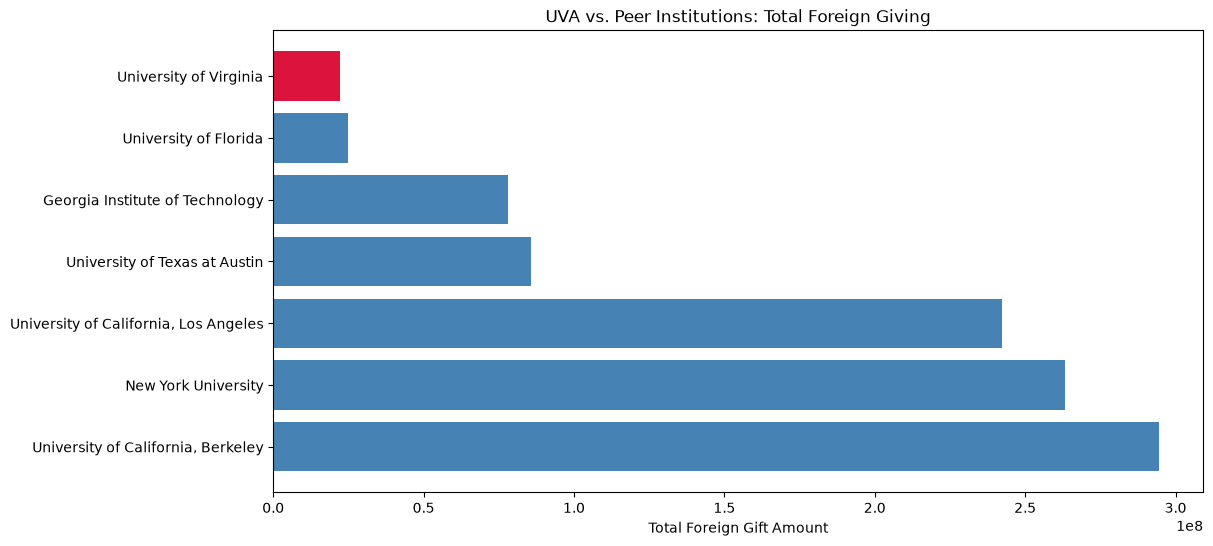

In [ ]:
#peer gap viz
# making df of just uva and peers
combo = df[df["Institution Name"].isin(peer_list + ["University of Virginia"])]

combo_totals = combo.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)
colors = ['crimson' if inst == 'University of Virginia' else 'steelblue' for inst in combo_totals.index]

plt.figure(figsize=(12, 6))
         # the inst names    # the total foreign giving
plt.barh(combo_totals.index, combo_totals.values, color=colors)
plt.xlabel("Total Foreign Gift Amount")
plt.title("UVA vs. Peer Institutions: Total Foreign Giving")
plt.show()

At the institution level, the scale of the gap is stark: the six peer institutions received $988.3M in foreign gifts combined over the same period, versus UVA's $22.2M — UVA captured roughly 2% of what its peer group brought in. Even UVA's closest peer by total foreign giving, University of Florida ($24.8M), only modestly outpaces UVA, while Berkeley ($294.5M), NYU ($263.1M), and UCLA ($242.1M) are operating in a different league entirely.

In [ ]:
# creating specific year column so i can do some groupby with multiple
df["Year"] = df["Foreign Gift Received Date"].dt.year

Year,2014,2015,2016,2017,2018,2019,2020
Country of Giftor,,,,,,,
QATAR,323711898.0000,468695933.0000,526132475.0000,456729528.0000,455768264.0000,475202771.0000,NaN
FRANCE,62944688.0000,69072584.0000,65094291.0000,79477592.0000,58820518.0000,70429723.0000,NaN
SWITZERLAND,65511449.0000,69462597.0000,73258877.0000,116093371.0000,116210925.0000,179362226.0000,NaN


In [23]:
country_year_trend = (
    df.groupby(["Country of Giftor", "Year"])["Foreign Gift Amount"]
    .sum()
    .unstack(fill_value=0)
)
country_year_trend.loc[["CHINA", "ENGLAND", "JAPAN", "SAUDI ARABIA", "SWITZERLAND"]]

Year,2014,2015,2016,2017,2018,2019,2020
Country of Giftor,,,,,,,
CHINA,90475886,85407936,225089200,185638077,332962872,312741998,5636143
ENGLAND,148236489,225451404,181172838,236976253,258011237,415058550,0
JAPAN,67744170,85888183,86360789,97687256,120113048,195438014,2723316
SAUDI ARABIA,168725991,153196605,141353011,162172041,165495402,272549147,1713733
SWITZERLAND,65511449,69462597,73258877,116093371,116210925,179362226,0


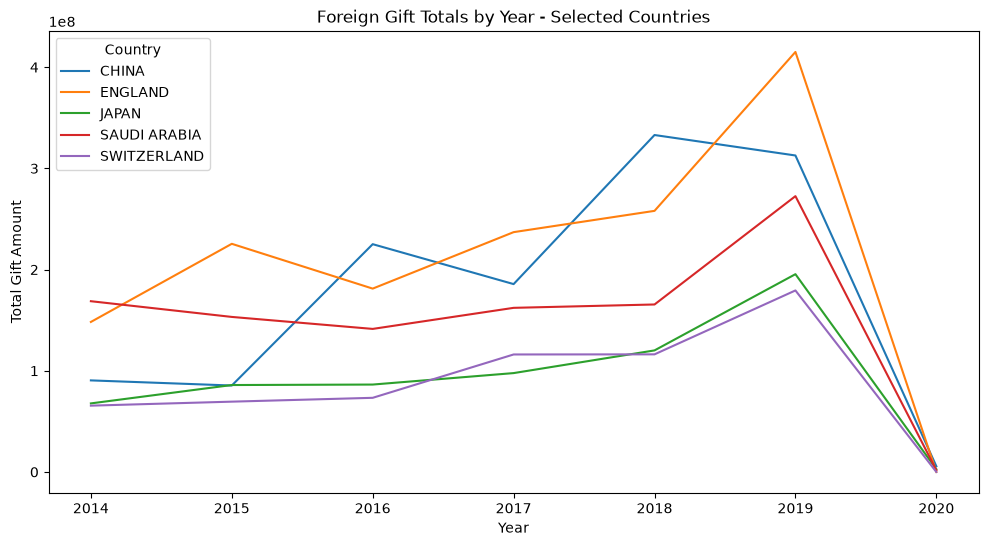

In [24]:
country_year_trend.loc[["CHINA", "ENGLAND", "JAPAN", "SAUDI ARABIA", "SWITZERLAND"]].T.plot(figsize=(12, 6))
plt.title("Foreign Gift Totals by Year - Selected Countries")
plt.ylabel("Total Gift Amount")
plt.xlabel("Year")
plt.legend(title="Country")
plt.show()

Year-over-year, China and Japan both show a clear multi-year growth trend across the dataset — China's total roughly quadruples from 2014 ($90.5M) to 2019 ($312.7M), and Japan nearly triples ($67.7M → $195.4M) — while Saudi Arabia stays relatively flat and England is volatile but trending upward through 2019. (The sharp drop shown for every country in 2020 is a data-coverage artifact: the dataset only runs through June 30, 2020, not a real collapse in giving.) China and Japan's upward trajectories make them the more time-sensitive opportunities — UVA has no current foothold with either, and they're live, growing markets rather than one-time spikes.

In [ ]:
peer_df[peer_df["Country of Giftor"].isin(["CHINA", "SAUDI ARABIA"])].groupby(
    ["Country of Giftor", "Gift Type"]
)["Foreign Gift Amount"].sum()

# checking to see if UVA is actually getting no gifts from these countries due to a giving pattern or because they only fund via a certain gift type
# not true, just no relationship

Country of Giftor  Gift Type    
CHINA              Contract         59812517
                   Monetary Gift    67053669
SAUDI ARABIA       Contract         60946652
                   Monetary Gift     8615826
Name: Foreign Gift Amount, dtype: int64

China's peer giving splits nearly evenly between contracts ($59.8M) and monetary gifts ($67.1M), while Saudi Arabia's is contract-heavy ($60.9M contract vs. $8.6M monetary). Since UVA receives $0 from both countries regardless of gift type, the absence isn't explained by UVA only being set up to accept one kind of gift — it's a genuine relationship gap, not a structural mismatch.

In [20]:
# what is UVA already good at
uva.groupby("Gift Type")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Gift Type
Contract         14807636
Monetary Gift     7381602
Name: Foreign Gift Amount, dtype: int64

## Strategy & Recommendations

UVA's existing $22.2M in foreign giving skews toward contracts ($14.8M — sponsored research/consulting-style agreements) over monetary gifts ($7.4M). That's a useful asset: Saudi Arabia's peer giving is similarly contract-heavy, so UVA's existing infrastructure for structuring research contracts is a natural fit for approaching Saudi funders, more so than for countries whose giving leans philanthropic.

1. **China and Saudi Arabia — the clearest near-term targets.** Both are proven, large-scale funders of UVA's peer institutions ($126.9M and $69.6M respectively) with zero current UVA relationship. Saudi Arabia's contract-heavy pattern plays to UVA's existing strength in sponsored agreements; China's roughly even split between contracts and monetary gifts means UVA should pursue both a research-partnership track and a development/major-gifts track in parallel.
2. **England, Japan, and Switzerland — expansion targets rather than cold outreach.** UVA already has relationships here (31, 6, and 2 gifts respectively), just far below peer scale. Growing an existing relationship is lower-risk than building one from zero.
3. **China and Japan are time-sensitive.** Both show sustained multi-year growth in the broader dataset, so delaying outreach means competing against an increasingly entrenched set of peer-institution relationships.

Overall, UVA captures roughly 2% of what its peer group receives in foreign gifts. Closing even a modest fraction of the China/Saudi Arabia gap, while growing the England/Japan/Switzerland relationships, represents realistic, evidence-backed room for growth rather than a stretch goal.